# 05 — Anomaly Detection: Why Normalize Residuals First

Goal: understand why `detect_anomalies.py` doesn't just run Isolation Forest on
raw residuals, and what "anomalous" even means here — it is NOT the same thing
as "high sales." We'll build the confusion by hand first, then fix it, same
approach as notebook 02.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

np.random.seed(1)


## Step 1 — two series with very different personalities

Series A: a STABLE series — sells about the same amount every day, low variance.
Series B: a SPIKY series — naturally jumps around a lot, high variance, maybe a
promotional item.

Both are completely normal, healthy series. Neither is "wrong." Let's simulate 60
days of each.

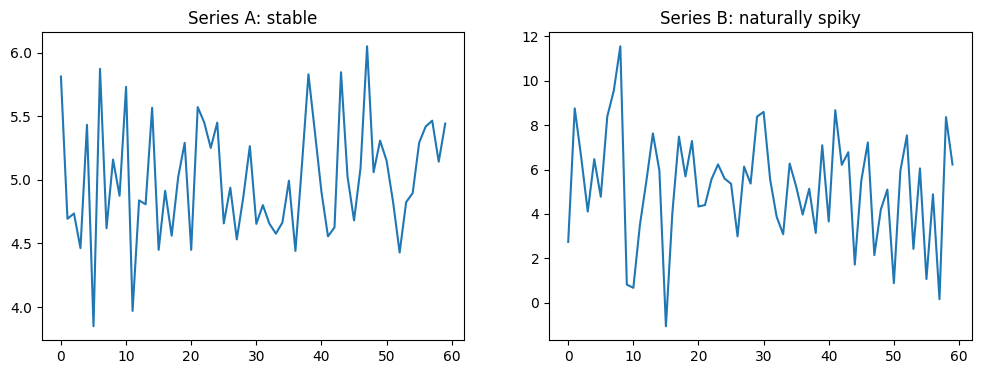

In [2]:
days = 60
series_a_forecast = np.full(days, 5.0)
series_a_actual = series_a_forecast + np.random.normal(0, 0.5, days)   # low noise

series_b_forecast = np.full(days, 5.0)
series_b_actual = series_b_forecast + np.random.normal(0, 3.0, days)   # high noise, naturally spiky

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(series_a_actual); axes[0].set_title("Series A: stable")
axes[1].plot(series_b_actual); axes[1].set_title("Series B: naturally spiky")
plt.show()


## Step 2 — inject ONE real anomaly into series A only

Let's say on day 40, series A has a genuinely unusual spike (maybe a viral social
post drove demand). Series B, meanwhile, just has one of its normal spiky days —
nothing special happening, just its usual volatility.

In [3]:
series_a_actual[40] = 5.0 + 8.0   # a real, unusual spike for this stable series
series_b_actual[40] = 5.0 + 8.0   # same absolute jump size, but for series B this is NOT unusual

residual_a = series_a_actual - series_a_forecast
residual_b = series_b_actual - series_b_forecast

print("Series A residual on day 40:", residual_a[40])
print("Series B residual on day 40:", residual_b[40])


Series A residual on day 40: 8.0
Series B residual on day 40: 8.0


**Both residuals are identical — exactly +8.0.** If you feed raw residuals into
Isolation Forest, it has no way to know that +8 is shocking for series A but
completely unremarkable for series B. It would treat these two very differently
meaningful events as the same thing.

In [6]:
# prove it: run Isolation Forest on RAW residuals only
raw_features = np.concatenate([residual_a, residual_b]).reshape(-1, 1)
labels = ['A']*days + ['B']*days

iforest_raw = IsolationForest(contamination=0.05, random_state=0)
raw_flags = iforest_raw.fit_predict(raw_features)

df_raw = pd.DataFrame({'series': labels, 'residual': raw_features.flatten(), 'flag': raw_flags})
df_raw[df_raw['flag'] == -1]  # -1 means flagged as anomaly


,series,residual,flag
40,A,8.000000,-1
67,B,4.559450,-1
68,B,6.556726,-1
75,B,-6.066604,-1
100,B,8.000000,-1
117,B,-4.847317,-1


Depending on the random seed, you'll likely see day-40 flagged for series A
(correct!) but ALSO some of series B's normal spiky days getting flagged just
because they happen to have large raw residuals — even though nothing unusual is
actually happening for series B. That's a false positive baked in by using raw
residuals across series with different natural volatility.

## Step 3 — the fix: normalize by each series' own rolling volatility

This is exactly `normalized_residual = residual / resid_roll_std` in
`detect_anomalies.py`. Divide each series' residual by ITS OWN typical
volatility, so "how many standard deviations away from this series' normal
behavior is this" becomes the shared, comparable scale — instead of raw units.

In [8]:
std_a = residual_a[:40].std()  # this series' own typical volatility (excluding the injected spike)
std_b = residual_b[:40].std()

norm_residual_a = residual_a / std_a
norm_residual_b = residual_b / std_b

print(f"Series A: raw residual on day 40 = {residual_a[40]:.2f}, normalized = {norm_residual_a[40]:.2f}")
print(f"Series B: raw residual on day 40 = {residual_b[40]:.2f}, normalized = {norm_residual_b[40]:.2f}")


Series A: raw residual on day 40 = 8.00, normalized = 16.59
Series B: raw residual on day 40 = 8.00, normalized = 3.28


Now the two numbers tell a very different story: series A's day-40 spike is
MANY standard deviations away from its own normal behavior (genuinely shocking),
while series B's day-40 spike is within its usual range once you account for how
volatile series B naturally is (unremarkable). This is the comparison Isolation
Forest actually needs to make a fair judgment across series.

In [9]:
norm_features = np.concatenate([norm_residual_a, norm_residual_b]).reshape(-1, 1)
iforest_norm = IsolationForest(contamination=0.05, random_state=0)
norm_flags = iforest_norm.fit_predict(norm_features)

df_norm = pd.DataFrame({'series': labels, 'normalized_residual': norm_features.flatten(), 'flag': norm_flags})
df_norm[df_norm['flag'] == -1]


,series,normalized_residual,flag
5,A,-2.386006,-1
11,A,-2.135749,-1
40,A,16.587208,-1
68,B,2.688142,-1
75,B,-2.487200,-1
100,B,3.279859,-1


Compare this result to Step 2's raw-residual version. With normalization, the
flagged points should cluster much more tightly around series A's real day-40
event, with far fewer of series B's normal volatility getting caught up as false
positives.

## Step 4 — this is why `roll_std` from notebook 02 comes back here

Remember notebook 02's rolling std feature? `resid_roll_std` in
`detect_anomalies.py` is computed the same shift-then-window way — a 14-day
rolling std of each series' OWN residuals. That's what `normalized_residual`
divides by. The two notebooks connect directly: the volatility feature you
learned to build safely (no leakage) is the exact denominator that makes anomaly
detection fair across series.

## Step 5 — what does `anomaly_score` actually mean, and why is it separate from `anomaly_flag`?

`anomaly_flag` is binary (0/1) — a threshold decision (top 3% most unusual = 1).
`anomaly_score` is the continuous score Isolation Forest assigns BEFORE
thresholding — lower score = more anomalous. Two series-days can both be
flagged as anomalies, but one might be a borderline case and the other an
extreme outlier. The flag alone can't distinguish that; the score can.

This matters for the RAG/insight layer: a Demand Planning Agent (or a human
reading the dashboard) might want to prioritize the MOST anomalous cases first,
not treat all flagged rows as equally urgent. `anomaly_score` is what would
enable that prioritization — worth noting this is a real capability the current
insight cards don't fully exploit yet (a v1.1-style improvement, similar to the
card-rollup idea already parked).

## Check your understanding

1. Why do two series with the same raw residual value not necessarily represent
   equally unusual events?
2. What does `normalized_residual` measure, in one sentence?
3. How does this notebook connect back to the rolling-std feature from notebook 02?
4. What's the practical difference between `anomaly_flag` and `anomaly_score`,
   and when would you want to use the score instead of the flag?

## You've now covered the full ML layer

Notebooks 1-5 cover: raw data structure, leakage-safe feature engineering, why a
global model works, quantile loss and calibration, and volatility-aware anomaly
detection. This is the full reasoning chain behind `run_day1.py` — you should now
be able to defend every modeling choice in that script from first principles, not
just describe what it does.

Come back to notebook 04's Q4 and this notebook's answers when you assemble your
final project writeup — these are the exact questions worth having crisp,
confident answers to.